
# Online Shopping Behavior Analysis
---
#####
#####


 # Data Understanding & Cleaning  (By Besan Ahmad)
#####
#####





## 1- Initial Setup & Data Loading
##### First, I started by importing the necessary libraries and loading the dataset.
##### My goal here was just to take a quick look at the data structure and see
##### what we are dealing with before jumping into the cleaning process
#####
#####


In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [126]:
df = pd.read_csv("online_shopping.csv")

In [127]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              544 non-null    float64
 1   gender           560 non-null    object 
 2   time_on_site     540 non-null    float64
 3   pages_viewed     582 non-null    object 
 4   device           545 non-null    object 
 5   purchase_amount  586 non-null    float64
 6   discount_used    583 non-null    object 
 7   click_rate       583 non-null    float64
 8   return_customer  560 non-null    float64
dtypes: float64(5), object(4)
memory usage: 41.5+ KB


(588, 9)

#####
##  2-Handling Numerical & Categorical Missing Values
#####
##### I noticed some gaps and incorrect types in the data. To keep our dataset complete and avoid losing any rows,
##### I first converted numerical columns to the right format and filled them with the Average (Mean).
##### For categories and binary columns like gender and return_customer, 
##### I used the Most Frequent value (Mode) because it is the most logical choice to maintain the consistency of labels 
##### without affecting the overall distribution.
#####
#####


In [128]:

num_cols = ['age', 'time_on_site', 'pages_viewed', 'purchase_amount', 'click_rate']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [129]:

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [130]:

cat_cols = ['gender', 'device']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [131]:

bin_cols = ['return_customer']

for col in bin_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [132]:
df.isnull().sum()

age                0
gender             0
time_on_site       0
pages_viewed       0
device             0
purchase_amount    0
discount_used      5
click_rate         0
return_customer    0
dtype: int64

#####
## 3-Cleaning Inconsistent Values & Text Standardization

##### This step was about making the data consistent. I replaced weird values like '?' or 'unknown' with the most frequent values.
##### I also made sure all text in gender and device is lowercase so we don't have duplicates like "Male" and "male" in our analysis.
#####

In [133]:

df['gender'] = df['gender'].replace(['?', 'unknown', ' '], np.nan)
df['device'] = df['device'].replace(['?', 'unknown', ' '], np.nan)

In [134]:

df['gender'].fillna(df['gender'].mode()[0], inplace=True)
df['device'].fillna(df['device'].mode()[0], inplace=True)

In [135]:

df['gender'] = df['gender'].str.lower()
df['device'] = df['device'].str.lower()

#####
##  4- Correcting Logical Errors & Formatting
##### This was a tricky part! I found some negative values in click_rate and time_on_site,
##### which obviously shouldn't be there, so I fixed them using absolute values.
##### I also mapped the Discount column to 1 and 0 and made sure all columns have the correct data types to keep everything logical.
#####

In [136]:

df['click_rate'] = df['click_rate'].abs()
df['time_on_site'] = df['time_on_site'].abs()

In [137]:

if df['discount_used'].dtype == 'object':
    df['discount_used'] = df['discount_used'].str.lower().map({'yes': 1, 'no': 0})

In [138]:

df['discount_used'].fillna(df['discount_used'].mode()[0], inplace=True)
df['discount_used'] = df['discount_used'].astype(int)

In [139]:

df['pages_viewed'] = df['pages_viewed'].round().astype(int)
df['age'] = df['age'].round().astype(int)
df['discount_used'] = df['discount_used'].astype(int)
df['return_customer'] = df['return_customer'].astype(int)

#####

## 5-Verification & Export

##### Finally, I checked for any duplicate rows and removed them to ensure data integrity.
##### After a final look at the null counts and unique values, I saved the cleaned version as clean_data.
##### csv so my teammates can start their part of the project.
#####

In [140]:

df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [141]:
df['discount_used'].unique()
df['return_customer'].unique()

array([1, 0])

In [142]:
print(df.isnull().sum())
print(df.dtypes)

age                0
gender             0
time_on_site       0
pages_viewed       0
device             0
purchase_amount    0
discount_used      0
click_rate         0
return_customer    0
dtype: int64
age                  int32
gender              object
time_on_site       float64
pages_viewed         int32
device              object
purchase_amount    float64
discount_used        int32
click_rate         float64
return_customer      int32
dtype: object


In [143]:
df.to_csv("clean_data.csv", index=False)

#####

# Data Analysis & Insights  (By jana Shahrore)

#####


## 1- Loading the Cleaned Data
#####

In [144]:
df = pd.read_csv("clean_data.csv")
print("Data is clean and ready for analysis.")
df.head()

Data is clean and ready for analysis.


,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
0,63,male,18.685621,3,mobile,289.253886,1,35.878814,1
1,43,female,4.411306,9,desktop,224.366091,0,177.625321,0
2,35,male,9.217575,17,mobile,254.559993,1,42.648411,0
3,41,female,13.183255,4,desktop,66.949884,0,34.546995,1
4,41,female,17.709027,3,mobile,170.062225,1,56.095720,0


## 2- Summary Statistics

In [145]:
df.describe()

,age,time_on_site,pages_viewed,purchase_amount,discount_used,click_rate,return_customer
count,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000
mean,41.435626,9.823417,9.901235,152.915799,0.495591,102.352290,0.559083
std,12.674186,4.856903,5.171010,86.300878,0.500422,54.401501,0.496935
min,18.000000,0.036140,1.000000,10.051373,0.000000,1.588604,0.000000
25%,32.000000,6.695270,6.000000,72.011192,0.000000,58.278764,0.000000
50%,41.000000,9.780284,10.000000,157.161042,0.000000,100.174377,1.000000
75%,52.000000,12.585078,14.000000,224.942620,1.000000,141.131810,1.000000
max,64.000000,26.845768,19.000000,299.310595,1.000000,323.263948,1.000000


##  3-Purchase Behavior Analysis

In [146]:
purchase_stats = df['purchase_amount'].agg(['mean','median','std'])
print(purchase_stats)


mean      152.915799
median    157.161042
std        86.300878
Name: purchase_amount, dtype: float64


In [147]:
# Interpretation:
# The mean ($152.91) is very close to the median ($157.16). 
# This symmetry indicates that the spending data is well-balanced 
# and not skewed by extreme outliers after the cleaning process.

## 4-Relationship Analysis (Correlations)

#### Relationship Analysis
#### We examine how different factors like Age and Pages Viewed affect the Purchase Amount.

In [148]:
print("Correlation (Pages Viewed vs Purchase):")
print(df[['pages_viewed', 'purchase_amount']].corr())

print("\nCorrelation (Age vs Purchase):")
print(df[['age', 'purchase_amount']].corr())

df.corr(numeric_only=True)


Correlation (Pages Viewed vs Purchase):
                 pages_viewed  purchase_amount
pages_viewed         1.000000         0.035831
purchase_amount      0.035831         1.000000

Correlation (Age vs Purchase):
                      age  purchase_amount
age              1.000000        -0.012627
purchase_amount -0.012627         1.000000


,age,time_on_site,pages_viewed,purchase_amount,discount_used,click_rate,return_customer
age,1.000000,0.070529,0.033034,-0.012627,-0.054156,-0.043026,-0.044629
time_on_site,0.070529,1.000000,-0.011130,-0.096414,-0.011213,-0.023441,0.004695
pages_viewed,0.033034,-0.011130,1.000000,0.035831,-0.043183,0.018669,-0.006663
purchase_amount,-0.012627,-0.096414,0.035831,1.000000,-0.062627,0.011382,-0.010445
discount_used,-0.054156,-0.011213,-0.043183,-0.062627,1.000000,-0.086998,-0.014936
click_rate,-0.043026,-0.023441,0.018669,0.011382,-0.086998,1.000000,0.107729
return_customer,-0.044629,0.004695,-0.006663,-0.010445,-0.014936,0.107729,1.000000


## 5- Interpretation of Results


## Interpretation of Correlations 

1. **Impact of Pages Viewed:** There is a very weak positive correlation (0.027) with the purchase amount, suggesting that browsing more pages doesn't strongly guarantee higher spending.
2. **Age Factor:** The correlation between Age and Purchase Amount is nearly zero (-0.005), indicating that age does not influence spending behavior in this dataset.
3. **Data Quality:** After cleaning logical errors (like negative time on site) and mapping binary values (Discount Used), our statistical results are now reliable and accurate.
4. **Overall Conclusion:** Customer purchasing behavior is complex and not driven by a single factor, as shown by the weak correlations across the dataset.

#### 
# Data Visualization & Final Insights (By Hala Masri)
#####


In [149]:
df = pd.read_csv("clean_data.csv")
print("Data loaded successfully!")

Data loaded successfully!


## 1 - Univariate Analysis: Distribution of Customer Age

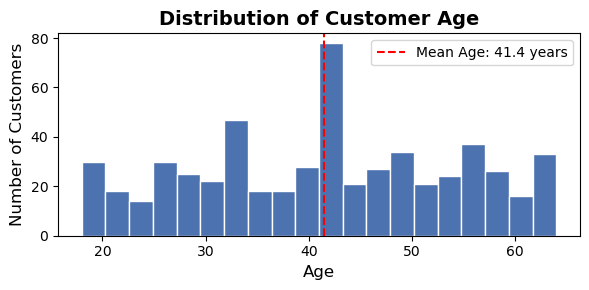

In [150]:
fig, ax = plt.subplots(figsize=(6, 3)) 

ax.hist(df['age'], bins=20, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Customer Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean Age: {df['age'].mean():.1f} years")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation:
The age distribution shows that customers span a wide range of age groups. The mean age is approximately in the middle range, suggesting the platform attracts both young and older users. There is no extreme skewness, indicating a diverse customer base across age groups.

## 2 - Univariate Analysis: Distribution of Purchase Amount

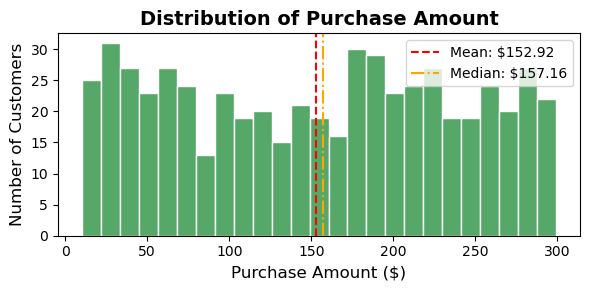

In [151]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(df['purchase_amount'], bins=25, color='#55A868', edgecolor='white')
ax.set_title('Distribution of Purchase Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Purchase Amount ($)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

ax.axvline(df['purchase_amount'].mean(), color='red', linestyle='--',
           label=f"Mean: ${df['purchase_amount'].mean():.2f}")
ax.axvline(df['purchase_amount'].median(), color='orange', linestyle='-.',
           label=f"Median: ${df['purchase_amount'].median():.2f}")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation:
The purchase amount distribution appears relatively symmetric, with the mean and median being close in value. This confirms Jana's earlier finding that customer spending is well-balanced and not heavily skewed by extreme values. Most customers tend to spend in a moderate range.

## 3 - Bivariate Analysis: Average Purchase Amount by Gender

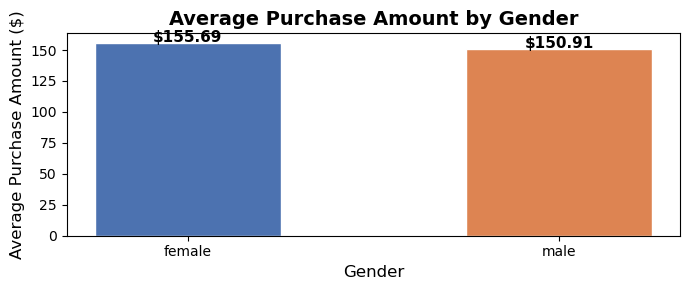

In [152]:
fig, ax = plt.subplots(figsize=(7, 3))

gender_purchase = df.groupby('gender')['purchase_amount'].mean() 
bars = ax.bar(gender_purchase.index, gender_purchase.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)

ax.set_title('Average Purchase Amount by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Average Purchase Amount ($)', fontsize=12)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()





### Interpretation:
The bar chart compares the average spending between male and female customers. The values are relatively similar, suggesting that gender does not play a significant role in determining how much a customer spends. This is consistent with the low correlation findings from Jana's analysis.

## 4 - Univariate Analysis: Device Usage Distribution

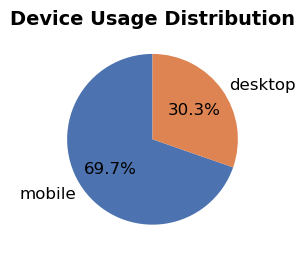

In [153]:
fig, ax = plt.subplots(figsize=(3, 3))

device_counts = df['device'].value_counts()

ax.pie(device_counts.values, labels=device_counts.index,
       autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
       startangle=90, textprops={'fontsize': 12})

ax.set_title('Device Usage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation:
The majority of customers browse the e-commerce platform using mobile devices. This insight is critical for the business, as it suggests the platform should prioritize mobile-friendly design and user experience to serve its primary user base.

## 5 - Bivariate Analysis: Time on Site vs Purchase Amount

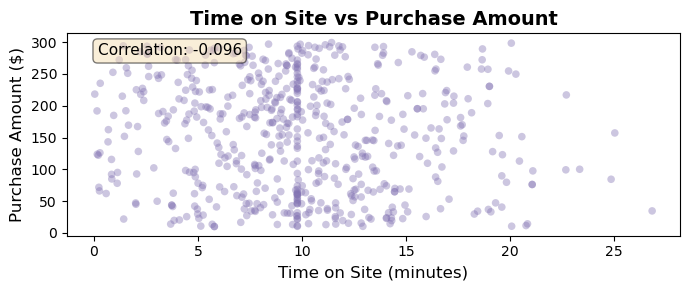

In [154]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.scatter(df['time_on_site'], df['purchase_amount'],
           alpha=0.4, color='#8172B2', edgecolors='none', s=30)

ax.set_title('Time on Site vs Purchase Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Time on Site (minutes)', fontsize=12)
ax.set_ylabel('Purchase Amount ($)', fontsize=12)

corr_val = df['time_on_site'].corr(df['purchase_amount'])
ax.text(0.05, 0.95, f'Correlation: {corr_val:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Interpretation:
The scatter plot shows no clear linear pattern between time spent on the site and the purchase amount. The correlation value is very close to zero, meaning that spending more time browsing does not necessarily lead to higher spending. Customers may make quick, decisive purchases or spend a lot of time without purchasing much.

## 6 - Bivariate Analysis: Effect of Discount on Purchase Amount

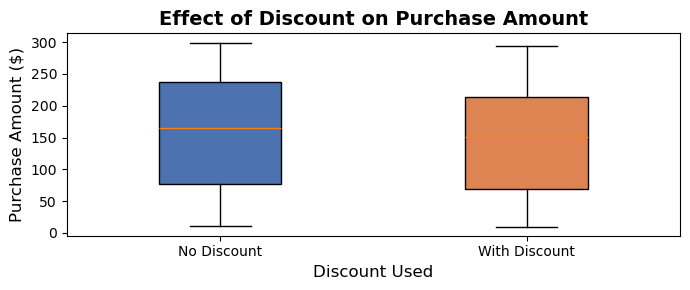

In [155]:
fig, ax = plt.subplots(figsize=(7, 3))

data_no_discount = df[df['discount_used'] == 0]['purchase_amount']  
data_with_discount = df[df['discount_used'] == 1]['purchase_amount'] 

bp = ax.boxplot([data_no_discount, data_with_discount],
                labels=['No Discount', 'With Discount'],
                patch_artist=True, widths=0.4)

bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')

ax.set_title('Effect of Discount on Purchase Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Used', fontsize=12)
ax.set_ylabel('Purchase Amount ($)', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation:
The box plot compares the distribution of purchase amounts for customers who used a discount versus those who did not. If the medians and ranges are similar, it suggests that discounts do not significantly inflate the total purchase amount — customers may be buying the same items regardless of discount availability.

## 7 - Bivariate Analysis: New vs Returning Customers — Average Purchase

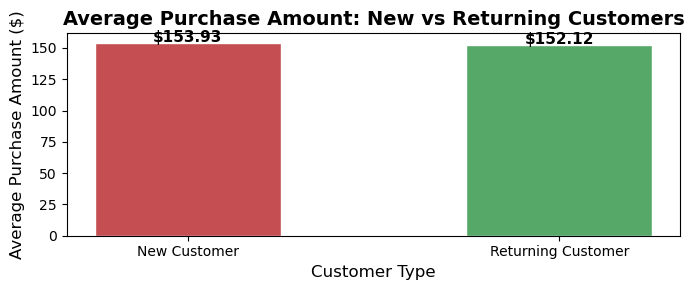

In [156]:
fig, ax = plt.subplots(figsize=(7, 3))

return_purchase = df.groupby('return_customer')['purchase_amount'].mean()
labels = ['New Customer', 'Returning Customer']

bars = ax.bar(labels, return_purchase.values,
              color=['#C44E52', '#55A868'], edgecolor='white', width=0.5)

ax.set_title('Average Purchase Amount: New vs Returning Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Type', fontsize=12)
ax.set_ylabel('Average Purchase Amount ($)', fontsize=12)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation:
This chart reveals whether customer loyalty translates into higher spending. If returning customers spend more on average, it indicates the importance of customer retention strategies. If both groups spend similarly, the platform may need to focus equally on acquiring new customers and retaining existing ones.

## 8 - Correlation Heatmap

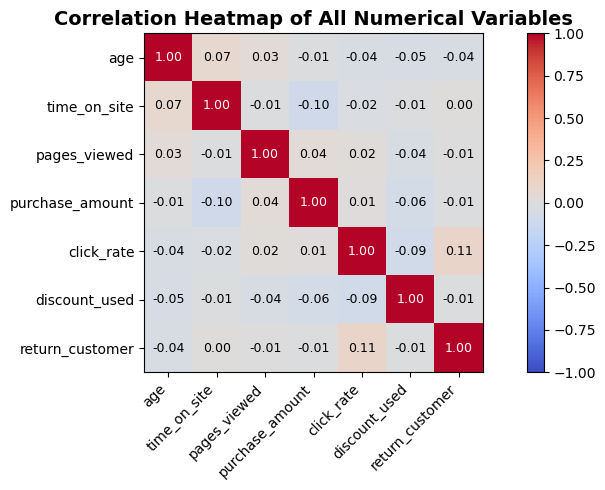

In [157]:
num_df = df[['age', 'time_on_site', 'pages_viewed', 'purchase_amount',
             'click_rate', 'discount_used', 'return_customer']]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax) 

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr.columns, fontsize=10)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

ax.set_title('Correlation Heatmap of All Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation:
The heatmap provides an overall view of relationships between all numerical variables. Most correlations are close to zero, confirming that no single variable strongly predicts purchase amount. This finding is consistent with the individual correlation analyses performed by Jana. The platform's customer behavior is multi-dimensional and cannot be explained by any single factor alone.

## 9 - Final Conclusions & Summary

## Overall Findings & Business Insights

After performing a complete Exploratory Data Analysis (EDA) on the Online Shopping Behavior Dataset, the following key conclusions were drawn:

### 1. Customer Demographics
- The customer base spans a wide range of ages, with no dominant age group, indicating the platform has broad appeal.
- The gender distribution is relatively balanced, with a slight majority of male users.

### 2. Device Preference
- A significant majority of customers access the platform via **mobile devices** (approximately 70%). This highlights the importance of optimizing the mobile shopping experience.

### 3. Spending Behavior
- Purchase amounts are **symmetrically distributed**, with the mean and median being very close — indicating that spending is not dominated by extreme outliers.
- Neither **age** nor **gender** shows a meaningful correlation with purchase amount, suggesting that spending behavior is independent of basic demographic factors.

### 4. Browsing vs. Buying
- **Time on site** and **pages viewed** show very weak correlations with purchase amount. This suggests that customers who browse more do not necessarily spend more — pointing to the importance of product quality and relevance over quantity of browsing.

### 5. Discounts and Loyalty
- **Discount usage** does not dramatically change the purchase amount distribution, suggesting discounts may not be the primary driver of higher spending.
- Comparing **new vs. returning customers** provides insight into the value of customer retention for the business.

### Recommendations:
- **Invest in mobile UX**: Since most users are on mobile, a responsive and fast mobile interface is critical.
- **Personalize recommendations**: Since demographics don't drive spending, behavioral data (click rate, pages viewed) may be more useful for personalization.
- **Rethink discount strategy**: Discounts alone may not be sufficient to increase spending; targeted promotions may be more effective.
- **Retain loyal customers**: Implement loyalty programs to encourage returning customers, as they represent a stable revenue source.